# Day 03. 선형회귀

## 1) 오늘의 학습 목표

- 모델을 `입력 → 계산 → 예측` 함수로 바라본다.
- 선형 모델의 가중치와 편향이 어떤 의미인지 이해한다.
- NumPy와 PyTorch로 같은 회귀 학습 흐름을 비교한다.
- `nn.Sequential`, 손실함수, optimizer의 역할을 가볍게 익힌다.


## 2) 선형회귀

선형회귀는 입력에 가중치를 곱하고 편향을 더해 연속적인 숫자를 예측합니다.  
`예측값 = X @ w + b`라는 단순한 구조지만, 딥러닝의 `Linear Layer`와 같은 핵심 계산 흐름을 담고 있습니다.

* 가중치(weight, w): 입력 x가 출력 y에 미치는 영향력의 크기이자 중요도를 나타냅니다. x가 양으로 커지면 y가 양으로 크게 증가하고, x가 음의 방향으로 커지만 y가 크게 감소합니다. w가 0에 가까우면 x는 y를 예측하는데 별로 중요하지 않은 변수라는 뜻입니다.

* 편향(bias, b): 입력 x가 모두 0일 때, 출력 y가 갖는 기본값을 말합니다. 편향은 직선을 위아래로 평행이동시켜서 실제 데이터 위치에 그래프를 맞추도록 하는 유연성을 모델에 부여합니다.


## 3) 예제: 입력 특성 2개로 예측하기

공부 시간과 지난 퀴즈 점수로 최종 점수를 예측하는 작은 데이터를 만듭니다.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import matplotlib.font_manager as fm

# ubuntu-터미널에 sudo apt install -y fonts-nanum

# 시스템에 설치된 폰트 중 'Nanum'이 포함된 폰트 이름 전체 출력
font_list = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]

# 우분투에 설치한 나눔고딕으로 설정
plt.rc('font', family='NanumGothic')

# 마이너스 기호 깨짐 방지
plt.rc('axes', unicode_minus=False)

plt.rcParams["figure.figsize"] = (6, 4)

rng = np.random.default_rng(7)
study_hours = np.array([1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7], dtype=float)
previous_score = np.array([55, 60, 58, 65, 70, 68, 75, 78, 80, 83, 85, 88], dtype=float)
final_score = 20 + 6.0 * study_hours + 0.55 * previous_score + rng.normal(0, 2.0, size=12)

data = pd.DataFrame({
    "study_hours": study_hours,
    "previous_score": previous_score,
    "final_score": final_score.round(1),
})
data


,study_hours,previous_score,final_score
0,1.0,55.0,56.3
1,2.0,60.0,65.6
2,2.0,58.0,63.4
3,3.0,65.0,72.0
4,3.0,70.0,75.6
5,4.0,68.0,79.4
6,4.0,75.0,85.4
7,5.0,78.0,95.6
8,5.0,80.0,93.0
9,6.0,83.0,100.4


## 4) 실습 1: 가중치와 편향으로 예측 계산하기

아직 학습하지 않은 임의의 가중치로 예측하면 오차가 큽니다.


In [12]:
X_raw = data[["study_hours", "previous_score"]].to_numpy()
y = data["final_score"].to_numpy()

w_guess = np.array([5.0, 1.0])
b_guess = 10.0
y_guess = X_raw @ w_guess + b_guess

mse_guess = np.mean((y_guess - y) ** 2)
print("임의 파라미터 MSE:", round(mse_guess, 2))
print("처음 5개 예측:", np.round(y_guess[:5], 1))
print("처음 5개 실제:", np.round(y[:5], 1))


임의 파라미터 MSE: 355.79
처음 5개 예측: [70. 80. 78. 90. 95.]
처음 5개 실제: [56.3 65.6 63.4 72.  75.6]


## 5) 실습 2: 표준화 후 선형회귀 학습하기

특성마다 단위가 다르면 학습이 불안정할 수 있어 평균 0, 표준편차 1에 가깝게되도록 데이터를 정규화시킵니다.


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54805 (\N{HANGUL SYLLABLE HYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54924 (\N{HANGUL SYLLABLE HOE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44480 (\N{HANGUL SYLLABLE GWI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/

학습된 w: [9.242 7.562]
학습된 b: 83.458
최종 MSE: 1.464


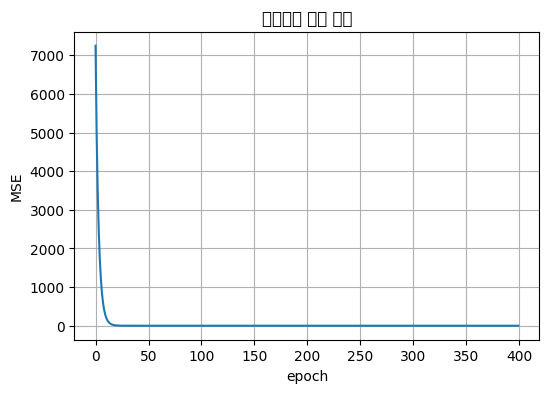

In [13]:
# 데이터 표준화
X_mean = X_raw.mean(axis=0)
X_std = X_raw.std(axis=0)
X = (X_raw - X_mean) / X_std

w = np.zeros(X.shape[1])
b = 0.0
lr = 0.08
losses = []

for epoch in range(400):
    pred = X @ w + b
    error = pred - y
    loss = np.mean(error ** 2)
    losses.append(loss)

    grad_w = 2 * np.mean(error[:, None] * X, axis=0)
    grad_b = 2 * np.mean(error)
    w -= lr * grad_w
    b -= lr * grad_b

print("학습된 w:", np.round(w, 3))
print("학습된 b:", round(b, 3))
print("최종 MSE:", round(losses[-1], 3))

plt.plot(losses)
plt.title("선형회귀 학습 손실")
plt.xlabel("epoch")
plt.ylabel("MSE")
plt.grid(True)
plt.show()


## 6) 실습 3: 예측 결과 확인하기

학습된 모델의 예측값과 실제값을 나란히 비교합니다.


,study_hours,previous_score,final_score,prediction,error
0,1.0,55.0,56.3,55.7,-0.6
1,2.0,60.0,65.6,64.5,-1.1
2,2.0,58.0,63.4,63.0,-0.4
3,3.0,65.0,72.0,73.2,1.2
4,3.0,70.0,75.6,76.8,1.2
5,4.0,68.0,79.4,80.6,1.2
6,4.0,75.0,85.4,85.5,0.1
7,5.0,78.0,95.6,92.9,-2.7
8,5.0,80.0,93.0,94.3,1.3
9,6.0,83.0,100.4,101.6,1.2


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

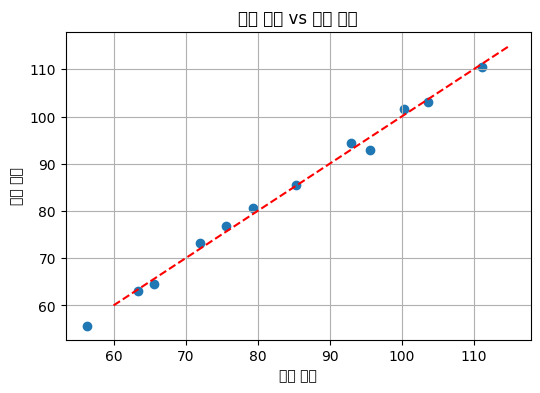

In [14]:
trained_pred = X @ w + b

result = data.copy()
result["prediction"] = trained_pred.round(1)
result["error"] = (result["prediction"] - result["final_score"]).round(1)
display(result)

plt.scatter(result["final_score"], result["prediction"])
plt.plot([60, 115], [60, 115], color="red", linestyle="--")
plt.title("실제 점수 vs 예측 점수")
plt.xlabel("실제 점수")
plt.ylabel("예측 점수")
plt.grid(True)
plt.show()


## 5) 실습 4: PyTorch로 선형회귀 구현

같은 데이터를 PyTorch로 학습해 보겠습니다. 구조는 `forward → loss 계산 → backward → step`입니다.  
NumPy에서는 우리가 gradient 식을 직접 썼지만, PyTorch에서는 `loss.backward()`가 gradient를 계산해 줍니다.


PyTorch device: cpu
마지막 PyTorch MSE: 1.2603175123126583e+19


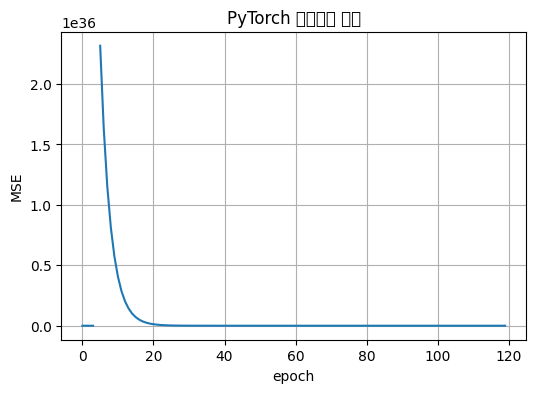

In [28]:
import torch

torch.manual_seed(7)    # 재현성을 위해 시드 고정
torch_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_tensor = torch.tensor(X, dtype=torch.float32, device=torch_device)
y_tensor = torch.tensor(y.reshape(-1, 1), dtype=torch.float32, device=torch_device)

torch_model = torch.nn.Sequential(
    torch.nn.Linear(2, 4),
    torch.nn.ReLU(),
    torch.nn.Linear(4, 8),
    torch.nn.ReLU(),
    torch.nn.Linear(8, 2),
    torch.nn.ReLU(),
    torch.nn.Linear(2, 1)
).to(torch_device)

loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.SGD(torch_model.parameters(), lr=0.08)  # Stochastic Gradient Descent
torch_losses = []

for epoch in range(120):
    optimizer.zero_grad()
    torch_pred = torch_model(X_tensor)
    torch_loss = loss_fn(torch_pred, y_tensor)
    torch_loss.backward()
    optimizer.step()
    torch_losses.append(float(torch_loss.detach().cpu()))

print("PyTorch device:", torch_device)
print("마지막 PyTorch MSE:", round(torch_losses[-1], 3))

plt.plot(torch_losses)
plt.title("PyTorch 선형회귀 손실")
plt.xlabel("epoch")
plt.ylabel("MSE")
plt.grid(True)
plt.show()


## 6) 실습 TODO: PyTorch 학습 설정 바꿔보기

`torch_lr`, `torch_epochs`를 바꾸면 손실이 얼마나 빨리 줄어드는지 달라집니다.


In [20]:
# TODO: torch_lr와 torch_epochs를 바꿔 마지막 손실을 비교해 보세요.
torch_lr = 0.05
torch_epochs = 120

todo_model = torch.nn.Sequential(torch.nn.Linear(2, 1)).to(torch_device)
todo_optimizer = torch.optim.SGD(todo_model.parameters(), lr=torch_lr)
todo_losses = []

for epoch in range(torch_epochs):
    todo_optimizer.zero_grad()
    todo_pred = todo_model(X_tensor)
    todo_loss = loss_fn(todo_pred, y_tensor)
    todo_loss.backward()
    todo_optimizer.step()
    todo_losses.append(float(todo_loss.detach().cpu()))

print("torch_lr:", torch_lr)
print("torch_epochs:", torch_epochs)
print("마지막 손실:", round(todo_losses[-1], 3))


torch_lr: 0.05
torch_epochs: 120
마지막 손실: 1.494


## 7) 미니 퀴즈

1. 회귀 문제와 분류 문제의 가장 큰 차이는 무엇인가요?
- 회귀: 예측값이 연속적인 실수
- 분류: 예측값이 이산적인 클래스


2. `X @ w + b`에서 `w`와 `b`는 각각 무엇을 의미하나요?
- 'w'는 가중치(weight)로 각 입력 특성(feature)이 결과에 미치는 영향력
- 'b'는 편향(bias)으로 예측값을 전체적으로 이동시키는 보정 상수(절편)


3. PyTorch 학습 루프에서 `optimizer.zero_grad()`를 먼저 호출하는 이유는 무엇인가요?
- PyTorch에서는 gradient가 기본적으로 누적(accumulate)되므로, 이전 step의 gradient가 남아있지 않도록 grad를 초기화하기 위해 호출한다.
- gradient 누적을 방지한다.


4. `loss.backward()`와 `optimizer.step()`은 각각 어떤 역할을 하나요?
- 'loss.backward()' : 역전파(backpropagation)를 수행하여 각 파라미터의 gradient(기울기)를 계산한다.
- 'optimizer.step()' : 계산된 gradient를 이용해 가중치와 편향을 업데이트한다.


5. 입력 특성을 표준화하면 어떤 장점이 있나요?
- 입력 특성의 단위(스케일) 차이를 줄여 학습을 안정화한다.
- 경사 하강법이 더 빠르게 수렴하도록 돕는다.

## 8) 오늘의 정리

- 선형회귀는 연속적인 숫자를 예측하는 가장 기본적인 모델입니다.
- 여러 입력 특성을 사용할 때도 핵심 계산은 `X @ w + b`입니다.
- PyTorch 학습 루프도 예측, 손실 계산, `backward()`, `step()` 순서로 반복됩니다.
